# Занятие 1. Введение и настройка окружения
## Курс: Нейросетевые методы обработки изображений

В этом ноутбуке мы:
1. Проверим версии установленных библиотек.
2. Установим недостающие пакеты (при необходимости).
3. Загрузим тестовый датасет CIFAR-10.
4. Визуализируем примеры изображений из датасета.
5. Исследуем структуру данных: форму тензоров, классы, нормализацию.

---
## Шаг 1. Проверка и установка зависимостей

Запустите ячейку ниже, чтобы убедиться, что все необходимые библиотеки доступны.  
Если какой-то пакет не установлен — раскомментируйте соответствующую строку с `!pip install`.

In [1]:
# --- Установка пакетов (раскомментируйте при необходимости) ---
# Для CPU-only установки PyTorch:
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
#
# Для GPU-версии (CUDA 12.4):
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
#
# TensorFlow / Keras:
# !pip install tensorflow
#
# Прочие библиотеки:
# !pip install matplotlib numpy pillow opencv-python

# --- Проверяем установленные версии ---
import importlib

# Словарь: имя модуля -> читаемое название
packages = {
    'torch':       'PyTorch',
    'torchvision': 'TorchVision',
    'tensorflow':  'TensorFlow/Keras',
    'matplotlib':  'Matplotlib',
    'numpy':       'NumPy',
    'PIL':         'Pillow',
    'cv2':         'OpenCV',
}

for pkg, name in packages.items():
    try:
        mod = importlib.import_module(pkg)
        version = getattr(mod, '__version__', '(версия недоступна)')
        print(f'[OK]  {name}: {version}')
    except ImportError:
        print(f'[НЕТ] {name}: не установлен — установите через pip')

[OK]  PyTorch: 2.12.1+cpu
[OK]  TorchVision: 0.27.1+cpu
[НЕТ] TensorFlow/Keras: не установлен — установите через pip
[OK]  Matplotlib: 3.11.0
[OK]  NumPy: 2.4.6
[OK]  Pillow: 12.3.0
[НЕТ] OpenCV: не установлен — установите через pip


---
## Шаг 2. Проверка доступности GPU

GPU значительно ускоряет обучение нейронных сетей.  
Если GPU недоступен — все примеры курса рассчитаны на работу на CPU
(с уменьшенными моделями и датасетами).

In [2]:
import torch

# Проверяем, доступен ли CUDA (GPU от NVIDIA)
cuda_available = torch.cuda.is_available()

if cuda_available:
    gpu_name = torch.cuda.get_device_name(0)
    print(f'GPU доступен: {gpu_name}')
    print(f'Количество GPU: {torch.cuda.device_count()}')
else:
    print('GPU не обнаружен. Используем CPU.')
    print('Для этого курса CPU достаточно при работе с небольшими датасетами.')

# Определяем устройство для вычислений.
# Эту переменную будем использовать во всех последующих занятиях:
#   model.to(device)  — переместить модель на нужное устройство
#   tensor.to(device) — переместить тензор
device = torch.device('cuda' if cuda_available else 'cpu')
print(f'\nАктивное устройство: {device}')

GPU не обнаружен. Используем CPU.
Для этого курса CPU достаточно при работе с небольшими датасетами.

Активное устройство: cpu


---
## Шаг 3. Базовые операции с тензорами PyTorch

В PyTorch все данные (изображения, веса, градиенты) представлены как **тензоры** (`torch.Tensor`) —
многомерные массивы, аналогичные `numpy.ndarray`, но с поддержкой GPU и автодифференцирования.

**Важное соглашение для изображений:**
- PyTorch использует формат **C × H × W** (каналы × высота × ширина).
- Matplotlib ожидает формат **H × W × C**.
- Для преобразования используем `tensor.permute(1, 2, 0)`.

In [3]:
import torch
import numpy as np

# --- Создание тензора, имитирующего одно RGB-изображение ---
# Формат: C × H × W = 3 × 64 × 64
img_tensor = torch.rand(3, 64, 64)  # значения равномерно распределены в [0, 1]
print('Форма тензора изображения (C × H × W):', img_tensor.shape)
print('Тип данных тензора:                  ', img_tensor.dtype)
print(f'Диапазон значений: [{img_tensor.min().item():.4f}, {img_tensor.max().item():.4f}]')

# --- Пакет изображений (batch) ---
# При обучении изображения передаются пачками (batch).
# Формат пакета: B × C × H × W, где B — размер батча
batch = torch.rand(8, 3, 64, 64)  # батч из 8 изображений 64×64
print('\nФорма батча (B × C × H × W):', batch.shape)

# --- Преобразование тензора в numpy для matplotlib ---
# permute меняет порядок осей: C×H×W → H×W×C
# .numpy() конвертирует тензор в numpy массив (работает только для CPU-тензоров)
img_np = img_tensor.permute(1, 2, 0).numpy()
print('\nФорма после permute для matplotlib (H×W×C):', img_np.shape)

Форма тензора изображения (C × H × W): torch.Size([3, 64, 64])
Тип данных тензора:                   torch.float32
Диапазон значений: [0.0002, 1.0000]

Форма батча (B × C × H × W): torch.Size([8, 3, 64, 64])

Форма после permute для matplotlib (H×W×C): (64, 64, 3)


---
## Шаг 4. Загрузка датасета CIFAR-10

**CIFAR-10** — классический учебный датасет из 60 000 цветных изображений 32×32 пикселя,
разделённых на 10 классов:
`airplane`, `automobile`, `bird`, `cat`, `deer`, `dog`, `frog`, `horse`, `ship`, `truck`.

При первом запуске датасет будет загружен (~170 МБ). Последующие запуски используют кэш в `./data`.

In [5]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# --- Определяем трансформации для обучающей выборки ---
# transforms.Compose объединяет несколько трансформаций в цепочку.
#
# transforms.ToTensor():
#   PIL Image (H×W×C, uint8 [0,255]) → тензор (C×H×W, float32 [0.0, 1.0])
#
# transforms.Normalize(mean, std):
#   Нормализует каждый канал: pixel_norm = (pixel - mean) / std
#   Значения mean и std для CIFAR-10 посчитаны заранее по всему датасету.
transform_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),   # среднее по каналам R, G, B
        std=(0.2470, 0.2435, 0.2616)     # стандартное отклонение по каналам R, G, B
    )
])

# --- Загружаем обучающую и тестовую выборки ---
# train=True  — обучающая выборка (50 000 изображений)
# train=False — тестовая выборка  (10 000 изображений)
# download=True — скачать датасет, если его нет локально
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=False, transform=transform_norm
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False, transform=transform_norm
)

# --- Создаём DataLoader — итератор для обхода датасета батчами ---
# batch_size  — количество изображений в одном батче
# shuffle     — перемешивать данные перед каждой эпохой (только для train!)
# num_workers — количество параллельных процессов загрузки (0 = главный поток)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0)

# --- Выводим сводную информацию ---
print(f'Обучающая выборка: {len(train_dataset):,} изображений')
print(f'Тестовая выборка:  {len(test_dataset):,} изображений')
print(f'Размер батча:      {train_loader.batch_size}')
print(f'Батчей в эпохе (train): {len(train_loader)}')

Обучающая выборка: 50,000 изображений
Тестовая выборка:  10,000 изображений
Размер батча:      32
Батчей в эпохе (train): 1563


---
## Шаг 5. Исследование структуры датасета

Посмотрим, как организованы данные: классы, метки, форма одного изображения, содержимое батча.

In [6]:
# --- Классы датасета ---
# train_dataset.classes — список строк: ['airplane', 'automobile', ...]
class_names = train_dataset.classes
print('Классы CIFAR-10:')
for idx, name in enumerate(class_names):
    print(f'  {idx}: {name}')

# --- Пример одного изображения ---
# dataset[i] вызывает __getitem__ и возвращает кортеж (image_tensor, label)
image, label = train_dataset[0]
print(f'\nПример изображения: тензор формы {image.shape}')
print(f'Метка класса: {label} ({class_names[label]})')
print(f'Диапазон значений после нормализации: [{image.min():.2f}, {image.max():.2f}]')

# --- Пример батча из DataLoader ---
# next(iter(loader)) извлекает первый батч без запуска полного цикла
images_batch, labels_batch = next(iter(train_loader))
print(f'\nФорма батча:        {images_batch.shape}')   # [32, 3, 32, 32]
print(f'Форма меток батча:  {labels_batch.shape}')    # [32]
print(f'Первые 8 меток:     {labels_batch[:8].tolist()}')
print(f'Классы первых 8:    {[class_names[l] for l in labels_batch[:8].tolist()]}')

Классы CIFAR-10:
  0: airplane
  1: automobile
  2: bird
  3: cat
  4: deer
  5: dog
  6: frog
  7: horse
  8: ship
  9: truck

Пример изображения: тензор формы torch.Size([3, 32, 32])
Метка класса: 6 (frog)
Диапазон значений после нормализации: [-1.99, 2.09]

Форма батча:        torch.Size([32, 3, 32, 32])
Форма меток батча:  torch.Size([32])
Первые 8 меток:     [4, 5, 6, 7, 5, 0, 9, 3]
Классы первых 8:    ['deer', 'dog', 'frog', 'horse', 'dog', 'airplane', 'truck', 'cat']


---
## Шаг 6. Визуализация изображений

Выведем случайные изображения **до нормализации**, чтобы видеть реальные цвета.  
Для этого загружаем датасет только с `ToTensor()` без нормализации.

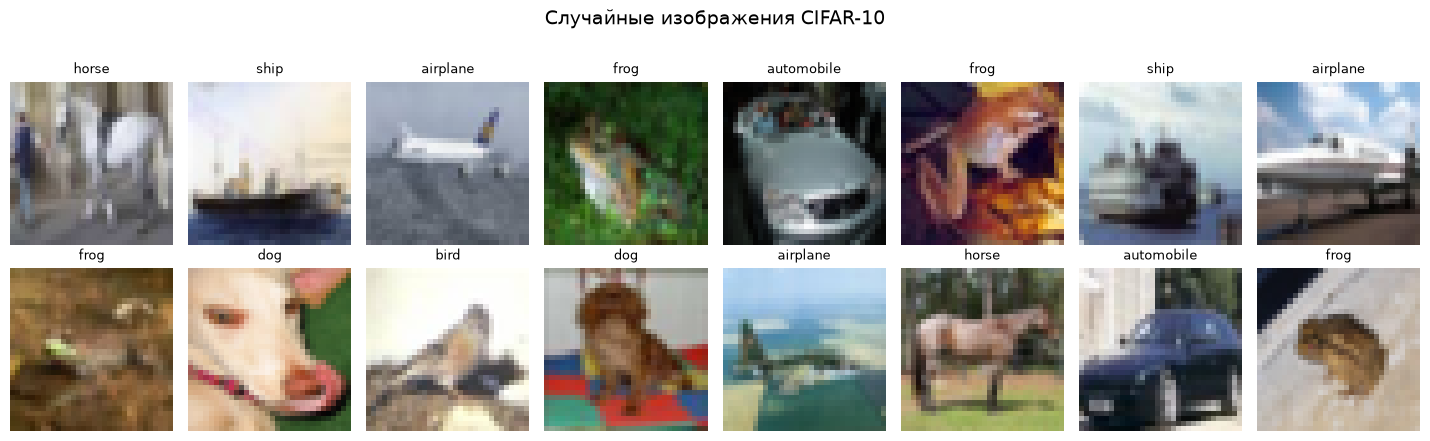

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Загружаем датасет БЕЗ нормализации — только ToTensor: значения в [0, 1]
dataset_vis = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False,
    transform=transforms.ToTensor()
)

def show_images_grid(dataset, class_names, n_rows=2, n_cols=8, seed=42):
    """
    Отображает сетку случайных изображений из датасета с подписями классов.

    Параметры:
        dataset     — датасет PyTorch (без нормализации, значения в [0,1])
        class_names — список строк с именами классов
        n_rows      — количество строк в сетке
        n_cols      — количество столбцов в сетке
        seed        — зерно генератора для воспроизводимости результата
    """
    np.random.seed(seed)
    indices = np.random.choice(len(dataset), n_rows * n_cols, replace=False)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.8, n_rows * 2.2))

    for ax, idx in zip(axes.flat, indices):
        img_tensor, label = dataset[idx]

        # permute: C×H×W (PyTorch) → H×W×C (matplotlib)
        img_np = img_tensor.permute(1, 2, 0).numpy()

        ax.imshow(img_np)               # отображаем изображение
        ax.set_title(class_names[label], fontsize=9)  # подпись класса
        ax.axis('off')                  # убираем оси

    plt.suptitle('Случайные изображения CIFAR-10', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Запускаем: сетка 2 × 8 изображений
show_images_grid(dataset_vis, class_names, n_rows=2, n_cols=8)

---
## Шаг 7. Распределение классов

Важно убедиться, что датасет **сбалансирован**: каждый класс представлен примерно
одинаковым количеством примеров. Несбалансированные датасеты требуют дополнительных мер
при обучении (взвешивание классов, стратифицированная выборка и т.п.).

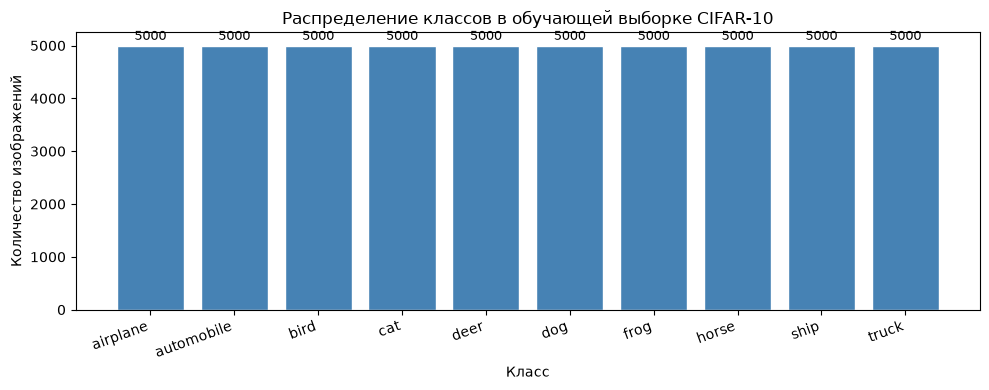

Вывод: CIFAR-10 полностью сбалансирован — 5000 изображений на каждый класс.


In [9]:
import matplotlib.pyplot as plt
from collections import Counter

# train_dataset.targets — список целочисленных меток всех изображений
label_counts = Counter(train_dataset.targets)

# Сортируем по индексу класса для единообразного порядка
classes_sorted = [class_names[i] for i in sorted(label_counts.keys())]
counts_sorted  = [label_counts[i] for i in sorted(label_counts.keys())]

plt.figure(figsize=(10, 4))
bars = plt.bar(classes_sorted, counts_sorted, color='steelblue', edgecolor='white')
plt.xlabel('Класс')
plt.ylabel('Количество изображений')
plt.title('Распределение классов в обучающей выборке CIFAR-10')
plt.xticks(rotation=20, ha='right')

# Подписываем числовые значения над каждым столбцом
for bar, count in zip(bars, counts_sorted):
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # горизонтальная позиция
        bar.get_height() + 50,              # чуть выше столбца
        str(count), ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.show()

print('Вывод: CIFAR-10 полностью сбалансирован — 5000 изображений на каждый класс.')

---
## Шаг 8. Визуализация эффекта нормализации

Нормализация приводит значения пикселей к стандартному диапазону
(нулевое среднее, единичное стандартное отклонение), что стабилизирует обучение.
Посмотрим, как меняется числовой диапазон изображения после нормализации.

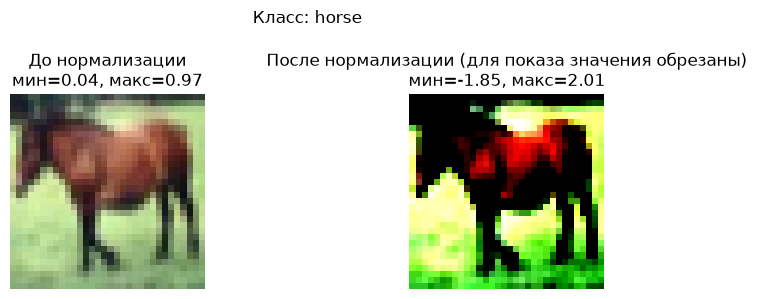

Важно: нейронная сеть получает нормализованные тензоры.
       Для визуализации нужно «отменить» нормализацию или использовать np.clip.


In [10]:
import matplotlib.pyplot as plt
import numpy as np

idx = 7  # индекс изображения для демонстрации (можно изменить)

# Изображение БЕЗ нормализации: значения в [0, 1]
img_raw, label = dataset_vis[idx]
img_raw_np = img_raw.permute(1, 2, 0).numpy()  # C×H×W → H×W×C

# Изображение ПОСЛЕ нормализации: значения могут выходить за [0, 1]
img_norm, _ = train_dataset[idx]
img_norm_np = img_norm.permute(1, 2, 0).numpy()

# clip нужен только для отображения: matplotlib не умеет рисовать значения < 0 или > 1
img_norm_clipped = np.clip(img_norm_np, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(9, 3))

axes[0].imshow(img_raw_np)
axes[0].set_title(
    f'До нормализации\nмин={img_raw_np.min():.2f}, макс={img_raw_np.max():.2f}'
)
axes[0].axis('off')

axes[1].imshow(img_norm_clipped)
axes[1].set_title(
    f'После нормализации (для показа значения обрезаны)\nмин={img_norm_np.min():.2f}, макс={img_norm_np.max():.2f}'
)
axes[1].axis('off')

plt.suptitle(f'Класс: {class_names[label]}', fontsize=12)
plt.tight_layout()
plt.show()

print('Важно: нейронная сеть получает нормализованные тензоры.')
print('       Для визуализации нужно «отменить» нормализацию или использовать np.clip.')

---
## Шаг 9. Примеры изображений одного класса

Полезно посмотреть на разнообразие изображений внутри одного класса.
Это помогает оценить сложность задачи: насколько разнообразны ракурсы, освещение, фон?

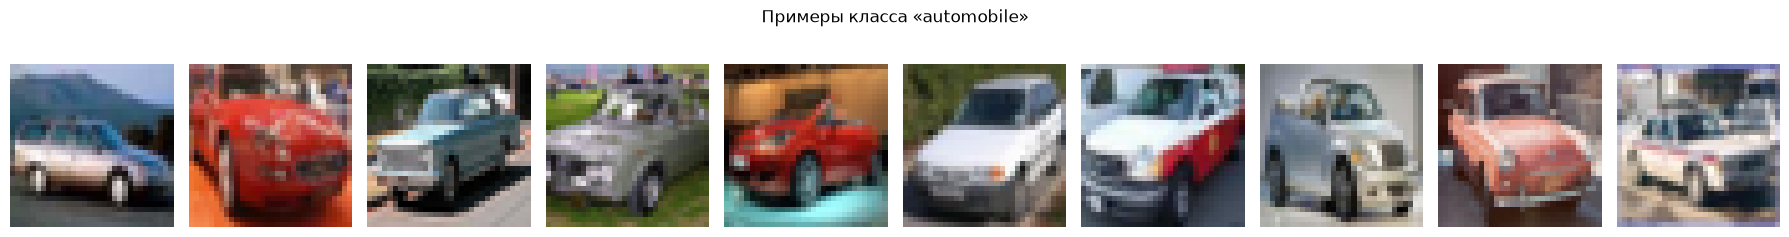

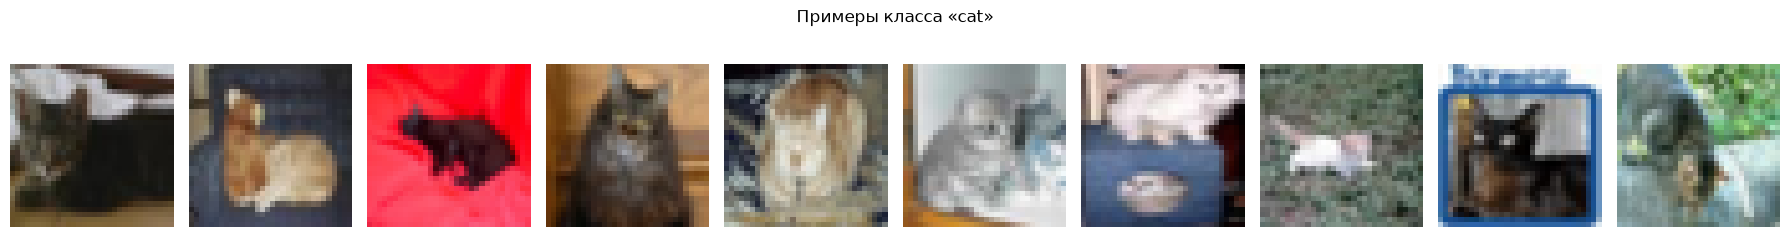

In [11]:
import matplotlib.pyplot as plt

def show_class_samples(dataset, class_names, target_class_idx, n_samples=10):
    """
    Отображает первые n_samples изображений заданного класса.

    Параметры:
        dataset           — датасет без нормализации
        class_names       — список имён классов
        target_class_idx  — индекс класса для отображения
        n_samples         — сколько примеров показать
    """
    # Отбираем индексы изображений нужного класса, берём первые n_samples
    indices = [
        i for i, (_, label) in enumerate(dataset)
        if label == target_class_idx
    ][:n_samples]

    fig, axes = plt.subplots(1, n_samples, figsize=(n_samples * 1.8, 2.5))
    class_name = class_names[target_class_idx]

    for ax, idx in zip(axes, indices):
        img_tensor, _ = dataset[idx]
        img_np = img_tensor.permute(1, 2, 0).numpy()  # C×H×W → H×W×C
        ax.imshow(img_np)
        ax.axis('off')

    plt.suptitle(f'Примеры класса «{class_name}»', fontsize=12)
    plt.tight_layout()
    plt.show()

# Показываем примеры класса 'automobile' (индекс 1)
show_class_samples(dataset_vis, class_names, target_class_idx=1, n_samples=10)

# Показываем примеры класса 'cat' (индекс 3)
show_class_samples(dataset_vis, class_names, target_class_idx=3, n_samples=10)

---
## Шаг 10. Гистограмма значений пикселей

Гистограмма распределения значений пикселей показывает особенности освещения
и баланс цветовых каналов. Если гистограммы каналов сильно различаются,
нормализация особенно важна.

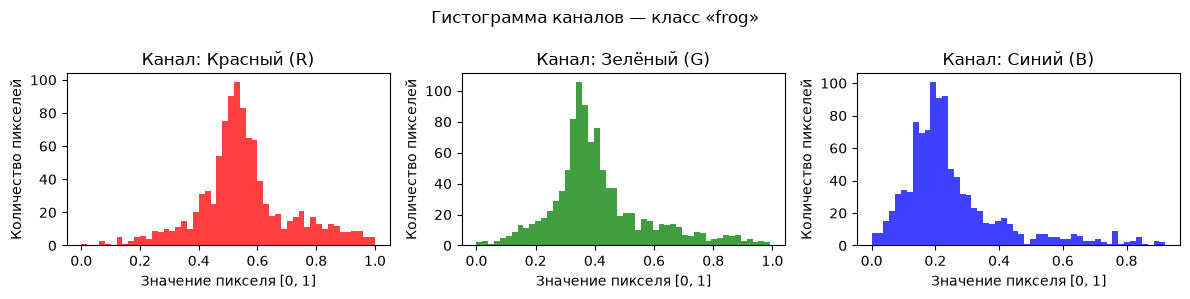

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Берём одно изображение без нормализации для анализа
img_tensor, label = dataset_vis[0]
img_np = img_tensor.numpy()   # форма: C × H × W, значения в [0, 1]

channel_names  = ['Красный (R)', 'Зелёный (G)', 'Синий (B)']
channel_colors = ['red', 'green', 'blue']

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for c, (ax, name, color) in enumerate(zip(axes, channel_names, channel_colors)):
    # img_np[c] — двумерный массив пикселей одного канала
    # .ravel()  — вытягиваем в одномерный вектор для гистограммы
    channel_data = img_np[c].ravel()

    ax.hist(channel_data, bins=50, color=color, alpha=0.75, edgecolor='none')
    ax.set_title(f'Канал: {name}')
    ax.set_xlabel('Значение пикселя [0, 1]')
    ax.set_ylabel('Количество пикселей')

plt.suptitle(f'Гистограмма каналов — класс «{class_names[label]}»', fontsize=12)
plt.tight_layout()
plt.show()

---
## Итоговая таблица: что мы освоили

| Тема | Результат |
|---|---|
| Проверка окружения | PyTorch, TensorFlow/Keras, matplotlib установлены |
| Работа с тензорами | Создание, формат C×H×W, `permute`, конвертация в numpy |
| Dataset | Загрузка CIFAR-10 через `torchvision.datasets` |
| DataLoader | Батч-итерирование, `shuffle`, `batch_size` |
| Нормализация | Визуализация эффекта нормализации пикселей |
| Визуализация | Сетки изображений, примеры по классам, гистограммы |

---
## Домашнее задание

1. Загрузите датасет **MNIST** (рукописные цифры) через `torchvision.datasets.MNIST`.
2. Выведите сетку **3 × 10** — по 10 примеров каждой цифры от 0 до 9.
3. Постройте гистограмму распределения яркостей для одного изображения MNIST.
4. Загрузите собственные изображения через `PIL.Image.open()`,
   конвертируйте в тензор с помощью `transforms.ToTensor()` и выведите через matplotlib.